In [2]:
import os
import nibabel as nib
import re
from typing import Optional


def extract_date(filename: str) -> Optional[str]:
    """Extract date in YYYYMMDD format from a NIfTI filename.
    
    Args:
        filename: Name of the NIfTI file (e.g., 'human_brain_20100513.nii.gz')
        
    Returns:
        str: Date in YYYYMMDD format if found, None otherwise
        
    Examples:
        >>> extract_date_from_nifti('human_brain_20100513.nii.gz')
        '20100513'
        >>> extract_date_from_nifti('scan_without_date.nii.gz')
        None
    """
    # Extract 8 consecutive digits that represent a date (YYYYMMDD)
    match = re.search(r'20\d{6}', filename)
    return match.group(0) if match else None



In [3]:
image_dir = "../../datasets/Craig_scans/T1_nifti"
t1_scans = sorted([f for f in os.listdir(image_dir) 
                         if f.endswith('.nii.gz') or f.endswith('.nii')])

print(t1_scans)
plots_path = "images_brain_Nyul"

['human_brain_20100204.nii.gz', 'human_brain_20100304.nii.gz', 'human_brain_20100407.nii.gz', 'human_brain_20100513.nii.gz', 'human_brain_20100826.nii.gz', 'human_brain_20100916.nii.gz', 'human_brain_20101111.nii.gz', 'human_brain_20110120.nii.gz', 'human_brain_20110224.nii.gz', 'human_brain_20110324.nii.gz', 'human_brain_20110428.nii.gz', 'human_brain_20110610.nii.gz', 'human_brain_20110707.nii.gz', 'human_brain_20110811.nii.gz', 'human_brain_20110915.nii.gz', 'human_brain_20111103.nii.gz', 'human_brain_20111117.nii.gz', 'human_brain_20120103.nii.gz', 'human_brain_20120126.nii.gz', 'human_brain_20120216.nii.gz', 'human_brain_20120315.nii.gz', 'human_brain_20120425.nii.gz', 'human_brain_20120607.nii.gz', 'human_brain_20120726.nii.gz', 'human_brain_20120919.nii.gz', 'human_brain_20121108.nii.gz', 'human_brain_20130118.nii.gz', 'human_brain_20130131.nii.gz', 'human_brain_20130314.nii.gz', 'human_brain_20130403.nii.gz', 'human_brain_20130510.nii.gz', 'human_brain_20130613.nii.gz', 'human_

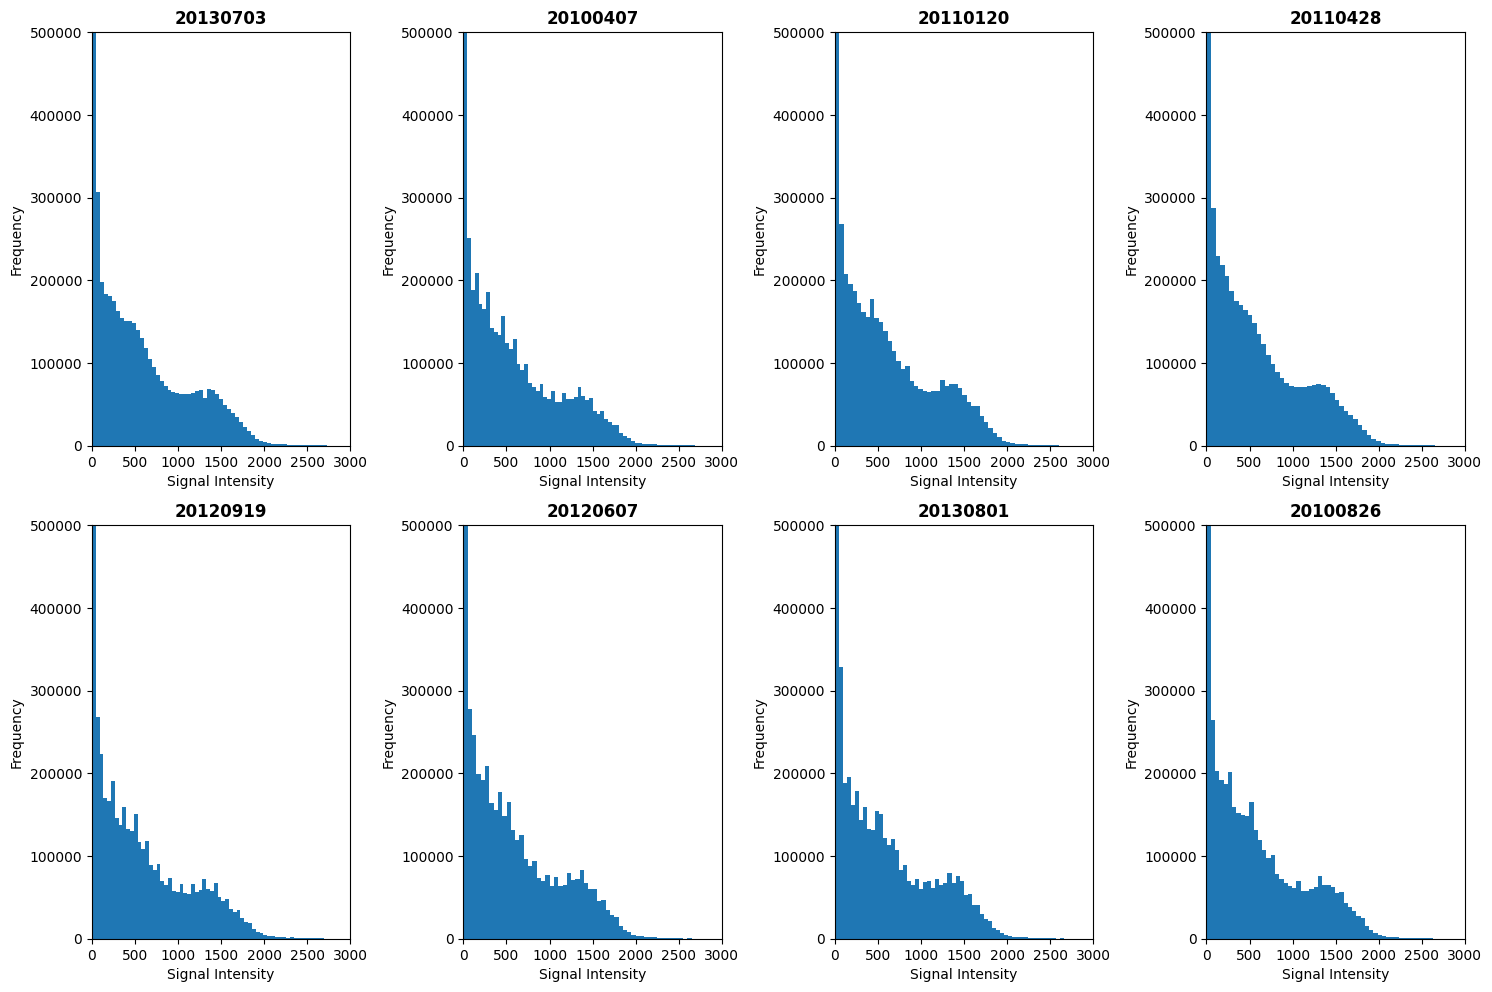

In [ ]:
# draw histogram of the t1_scans before the harmonization
import matplotlib.pyplot as plt
from pathlib import Path
import random
num_bins = 200

filter_threshold = 100
num_cols = 4
fig, axs = plt.subplots(2, num_cols, figsize=(15, 10))
cnt = 0  
random_images = random.sample(t1_scans, 8)
for scan_file in random_images:
    image_file = os.path.join(image_dir, scan_file)

    img = nib.load(image_file).get_fdata()

    scan_date = extract_date(image_file)

    axs[cnt//num_cols, cnt%num_cols].hist(img.flatten(), bins=num_bins)
    axs[cnt//num_cols, cnt%num_cols].set_title(scan_date, fontsize=12, fontweight='bold')
    axs[cnt//num_cols, cnt%num_cols].set_xlabel('Signal Intensity')
    axs[cnt//num_cols, cnt%num_cols].set_ylabel('Frequency')
    axs[cnt//num_cols, cnt%num_cols].set_xlim(0, 3000)
    axs[cnt//num_cols, cnt%num_cols].set_ylim(0, 5e5)
    cnt += 1

plt.tight_layout(pad=1.0)
plt.savefig(f'{plots_path}/brain_original_intensity_distribution_Nyul.png')
plt.show()

In [6]:
import numpy as np


# https://www.medrxiv.org/content/10.1101/2021.02.24.21252322v2.full
def get_percentile(image_data, percentile: float = 98):
    # Flatten the image array to 1D
    flat_data = image_data.flatten()
    
    # Remove background/zero values
    nonzero_data = flat_data[flat_data > 0]
    
    # Calculate the percentile
    p = np.percentile(nonzero_data, percentile)
    return p


def calculate_top_percentile_average(image_data: np.ndarray, 
                                   percentile: float = 99.99,
                                   remove_zeros: bool = True) -> float:
    # Flatten the array and remove zeros if specified
    flat_data = image_data.flatten()
    if remove_zeros:
        flat_data = flat_data[flat_data > 0]
    
    # Calculate the percentile threshold
    threshold = np.percentile(flat_data, percentile)
    
    # Get values above threshold
    top_values = flat_data[flat_data >= threshold]
    
    # Calculate average of values above threshold
    avg_value = np.mean(top_values)
    
    return avg_value

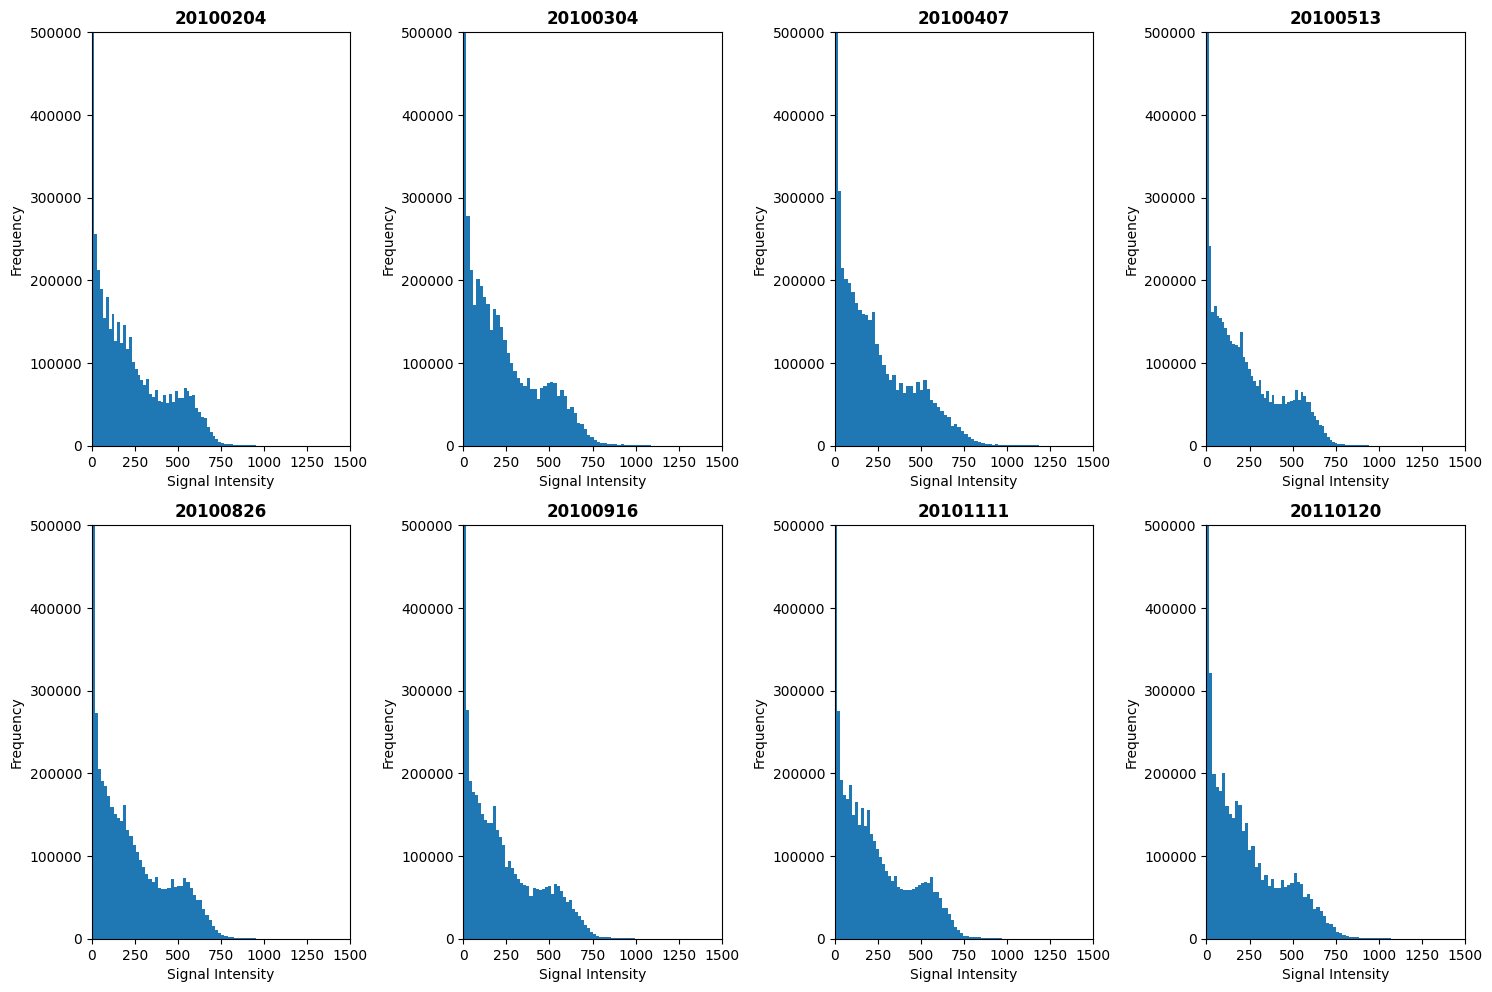

In [117]:
from intensity_normalization.normalize.nyul import NyulNormalize
import numpy as np
from pathlib import Path

original_images = []
scan_dates = []
for scan_file in t1_scans:
    image_file = os.path.join(image_dir, scan_file)
    img = nib.load(image_file).get_fdata()
    original_images.append(img)
    scan_date = extract_date(image_file)
    scan_dates.append(scan_date)


# For now we use 98th percentile as the threshold 
p98 = get_percentile(np.array(original_images), percentile=98)


normalizer = NyulNormalize(min_percentile=1, max_percentile=99.99, 
                           output_min_value=0, output_max_value=p98)

#normalizer = NyulNormalize()
normalizer.fit(original_images)

normalized_images = []
for image in original_images:
    normalized_image = normalizer(image)
    normalized_images.append(normalized_image)


# draw histogram of the normalized images
fig, axs = plt.subplots(2, num_cols, figsize=(15, 10))
cnt = 0 
for idx, normalized_image in enumerate(random.sample(normalized_images, 8)):
    axs[cnt//num_cols, cnt%num_cols].hist(normalized_image.flatten(), bins=num_bins)
    axs[cnt//num_cols, cnt%num_cols].set_title(scan_dates[idx], fontsize=12, fontweight='bold')
    axs[cnt//num_cols, cnt%num_cols].set_xlim(0, 1500)
    axs[cnt//num_cols, cnt%num_cols].set_ylim(0, 5e5)
    axs[cnt//num_cols, cnt%num_cols].set_xlabel('Signal Intensity')
    axs[cnt//num_cols, cnt%num_cols].set_ylabel('Frequency')
    cnt += 1

plt.tight_layout(pad=1.0)
plt.savefig(f'{plots_path}/brain_normalized_intensity_distribution_Nyul.png')
plt.show()



In [118]:

average_99_99p = calculate_top_percentile_average(np.array(original_images), 99.99, remove_zeros=True)

normalizer = NyulNormalize(min_percentile=1, max_percentile=99.99, 
                           output_min_value=0, output_max_value=average_99_99p)

#normalizer = NyulNormalize()
normalizer.fit(original_images)

normalized_images_av99p = []
for image in original_images:
    normalized_image = normalizer(image)
    normalized_images_av99p.append(normalized_image)

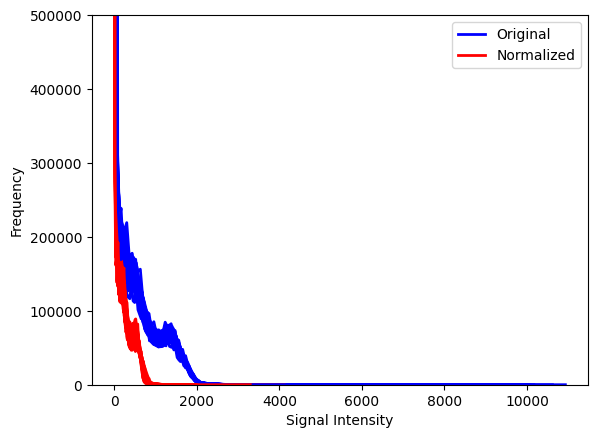

In [125]:

# draw histogram of the normalized images
for idx, normalized_image in enumerate(normalized_images):
    # plot the histogram of the original image
    hist_values, bin_edges = np.histogram(original_images[idx], bins=num_bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    plt.plot(bin_centers, hist_values, '-', linewidth=2, color='blue',  label='Original' if idx == 0 else "")

    # plot the histogram of the normalized image
    hist_values, bin_edges = np.histogram(normalized_image, bins=num_bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    plt.plot(bin_centers, hist_values, '-', linewidth=2, color='red',  label='Normalized' if idx == 0 else "")

    
#plt.title(scan_dates[idx], fontsize=12, fontweight='bold')
# plt.xlim(0, 000)
plt.ylim(0, 5e5)
plt.xlabel('Signal Intensity')
plt.ylabel('Frequency')
plt.legend(loc='upper right')
plt.savefig(f'{plots_path}/image_histogram_comparison_percetil.png')
plt.show()

(2,)


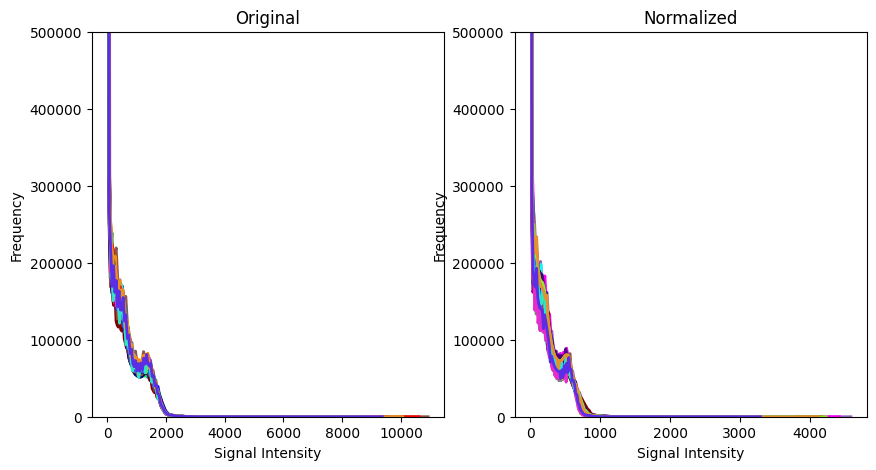

In [140]:
"""Utility functions for visualizing and comparing feature histograms."""

import numpy as np
import matplotlib.pyplot as plt
from typing import Union, List, Tuple
import seaborn as sns
import colorsys

def generate_distinct_colors(n: int) -> list:
    """Generate n visually distinct colors.
    
    Args:
        n: Number of colors to generate
        
    Returns:
        List of colors in hex format
    """
    colors = []
    
    # Start with some hand-picked distinct colors
    base_colors = [
        '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',  # Default matplotlib
        '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf',
        '#ff0000', '#00ff00', '#0000ff', '#ffff00', '#ff00ff',  # Pure RGB and CMYK
        '#00ffff', '#800000', '#008000', '#000080', '#808000',
        '#800080', '#008080', '#ff8c00', '#8b4513', '#483d8b',  # Dark and medium tones
        '#2f4f4f', '#556b2f', '#a0522d', '#4b0082', '#708090',
    ]
    colors.extend(base_colors)
    
    # If we need more colors, generate them using HSV color space
    if n > len(colors):
        remaining = n - len(colors)
        for i in range(remaining):
            # Generate colors by varying hue while keeping saturation and value fixed
            hue = (i * 0.618033988749895) % 1  # Use golden ratio to space out hues
            saturation = 0.8  # High saturation for distinctiveness
            value = 0.9  # High value but not too bright
            
            # Convert HSV to RGB
            rgb = colorsys.hsv_to_rgb(hue, saturation, value)
            
            # Convert RGB to hex
            hex_color = '#{:02x}{:02x}{:02x}'.format(
                int(rgb[0] * 255),
                int(rgb[1] * 255),
                int(rgb[2] * 255)
            )
            colors.append(hex_color)
    
    return colors[:n]

# Generate 37 distinct colors
COLORS = generate_distinct_colors(len(normalized_images))

num_cols = 2
fig, axs = plt.subplots(1, num_cols, figsize=(10, 5))
print(axs.shape)
# draw histogram of the normalized images
for idx, normalized_image in enumerate(normalized_images):
    # plot the histogram of the original image
    hist_values, bin_edges = np.histogram(original_images[idx], bins=num_bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    axs[0].plot(bin_centers, hist_values, '-', linewidth=2, color=COLORS[idx])

    # plot the histogram of the normalized image
    hist_values, bin_edges = np.histogram(normalized_image, bins=num_bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    axs[1].plot(bin_centers, hist_values, '-', linewidth=2, color=COLORS[idx])

    
#plt.title(scan_dates[idx], fontsize=12, fontweight='bold')
# plt.xlim(0, 000)
axs[0].set_xlabel('Signal Intensity')
axs[0].set_ylabel('Frequency')
axs[0].set_title('Original')
axs[0].set_ylim(0, 5e5)

axs[1].set_xlabel('Signal Intensity')
axs[1].set_ylabel('Frequency')
axs[1].set_title('Normalized')
axs[1].set_ylim(0, 5e5)
plt.savefig(f'{plots_path}/brain_image_histogram_original_normalized.png')
plt.show()